## Doublon dynamics in the Bose Hubbard Lieb Lattice in a strong coupling regime

#### Dynamics of a single particle localized in a random region

Imports

In [1]:
import src.bosehubbard.bosehubbard as bh
import numpy as np
import scipy
import scipy.sparse as sparse
from pyexpokit import expmv
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.bosehubbard.utils.lieb import lieb_lattice,occupation_number
from typing import List


Data

In [91]:
linear_dimension:int=3
hopping_energy:float=1.
interaction_coupling:float=10.
#omegas = [2*hopping_energy/(interaction_coupling*0.5)]*(linear_dimension)
omegas=[2*hopping_energy/(interaction_coupling*0.5)]*(3*linear_dimension**2)
for i in [0,3,6,8,15,17,25]:
    omegas[i]=hopping_energy/(interaction_coupling*0.5)
for i in [1,10,16,20,24]:
    omegas[i]=3*hopping_energy/(interaction_coupling*0.5)
for i in [4,7,13,16]:
    omegas[i]=4*hopping_energy/(interaction_coupling*0.5)

links:List=lieb_lattice(hopping_value=hopping_energy/(interaction_coupling*0.5),linear_dimension=linear_dimension)
#links:List=[[i, (i+1) % linear_dimension, hopping_energy**2/(interaction_coupling*0.5)] for i in range(linear_dimension)]
u:float = 0

model = bh.Model(omegas, links, u)

model_single_particle=model.numbersector(1)
hamiltonian=model_single_particle.hamiltonian

9
(27, 27)


Initialize the state

In [92]:
psi0=np.zeros(hamiltonian.shape[0])
#psi0=np.zeros(linear_dimension)


index=13 # random initial site
psi0[index]=1.
psi0=psi0/np.linalg.norm(psi0)

Dynamics of the single particle: Evolution Hyper-parameters

In [93]:
nstep=1000
time_sp=np.linspace(0.,100.,nstep)
dt=time_sp[1]-time_sp[0]
t_bar=tqdm(enumerate(time_sp))

0it [08:00, ?it/s]


Dynamics of the single particle: Exp Matrix evolution

In [94]:
psi=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_t=psi0.copy()
for i,t in enumerate(time_sp):
    psi[i,:]=psi_t  
    psi_t=expmv(dt,-1j*hamiltonian,psi_t)

Occupation Number

In [95]:
single_particle_n=occupation_number(psi=psi,basis=model_single_particle.basis.vs,size=psi_t.shape[-1])


(27, 27)


Analysis: Fidelity evolution

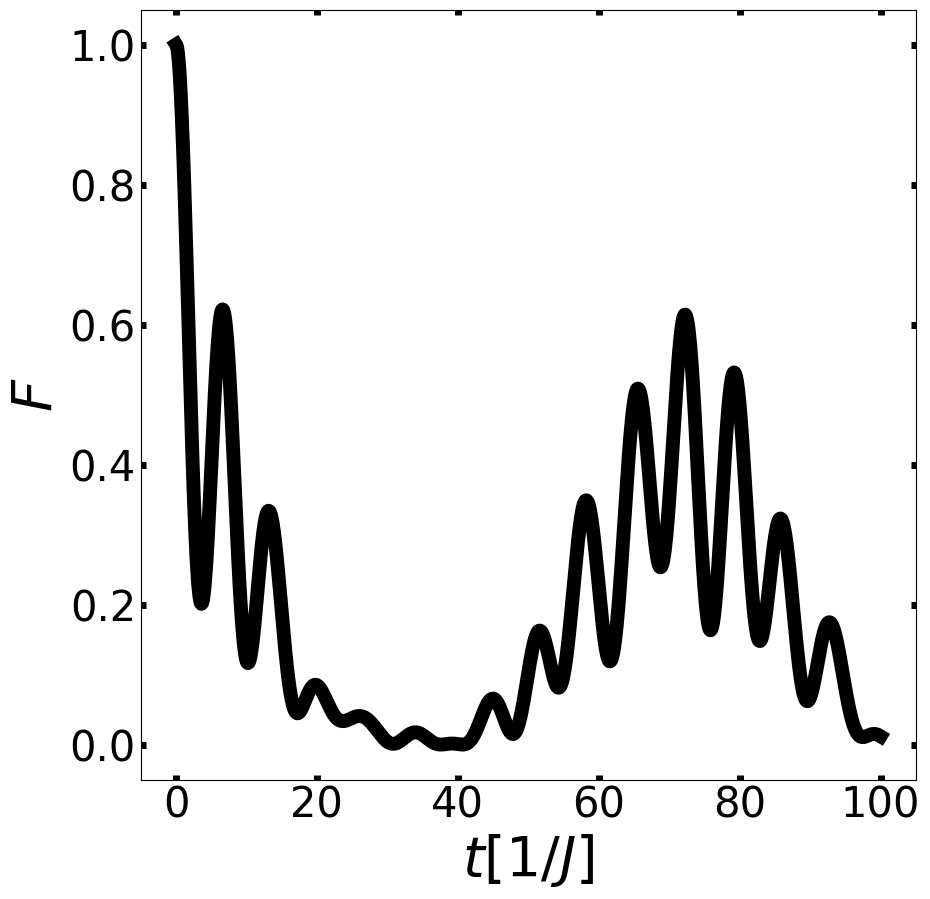

In [96]:


fidelity_single_particle:np.ndarray=np.real((np.einsum('ti,i->t',np.conjugate(psi),psi0)))**2+np.imag((np.einsum('ti,i->t',np.conjugate(psi),psi0)))**2

plt.figure(figsize=(10,10))
plt.plot(time_sp,fidelity_single_particle,color='black',linewidth=10)
plt.xlabel(r'$t[1/J]$',fontsize=40)
plt.ylabel(r'$F$',fontsize=40)
#plt.loglog()
plt.tick_params(
            top=True,
            right=True,
            labeltop=False,
            labelright=False,
            direction="in",
            labelsize=30,
            width=5,
        )
plt.tick_params(
            which='minor',
            top=True,
            right=True,
            labeltop=False,
            labelright=False,
            direction="in",
            labelsize=0,
            width=1,
            length=2
            
        )
plt.show()

Occupation Number

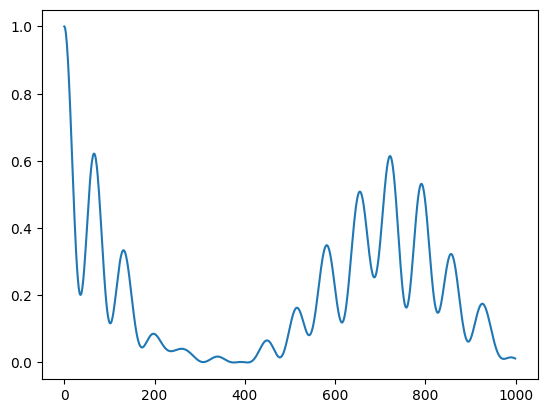

In [97]:

plt.plot(single_particle_n[:,13])
plt.show()

#### Doublon Dynamics in the regime of strong coupling $U \sim 5 J $

Imports

In [98]:
import src.bosehubbard.bosehubbard as bh
import numpy as np
import scipy
import scipy.sparse as sparse
from pyexpokit import expmv
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.bosehubbard.utils.lieb import lieb_lattice,occupation_number
from typing import List


Data

In [99]:
linear_dimension:int=3
hopping_energy:float=1.
omegas=[0]*(3*linear_dimension**2)
#omegas = [0]*(linear_dimension)
links:List=lieb_lattice(hopping_value=hopping_energy,linear_dimension=linear_dimension)
#links:List=[[i, (i+1) % linear_dimension, hopping_energy] for i in range(linear_dimension)]
model = bh.Model(omegas, links, interaction_coupling)

model_two_particles=model.numbersector(2)
hamiltonian=model_two_particles.hamiltonian
print(hamiltonian.shape)

9
(378, 378)
(378, 378)


Initialize the state

In [100]:
psi0=np.zeros(hamiltonian.shape[0])

# we need to find the indices related to the 2 particles in the site 24-th
state:np.ndarray=np.zeros(3*linear_dimension**2)
state[13]=2


index=model_two_particles.basis.index(state) # random initial site
print(index)
psi0[index]=1.
psi0=psi0/np.linalg.norm(psi0)

273


Dynamics of the single particle: Evolution Hyper-parameters

In [101]:
nstep=1000
time=np.linspace(0.,100.*hopping_energy,nstep)
dt=time[1]-time[0]
t_bar=tqdm(enumerate(time))

0it [01:01, ?it/s]


Dynamics of the single particle: Exp Matrix evolution

In [102]:
psi=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_t=psi0.copy()
for i,t in enumerate(time):
    psi[i,:]=psi_t  
    psi_t=expmv(dt,-1j*hamiltonian,psi_t)

Analysis: Fidelity evolution

(1000,)


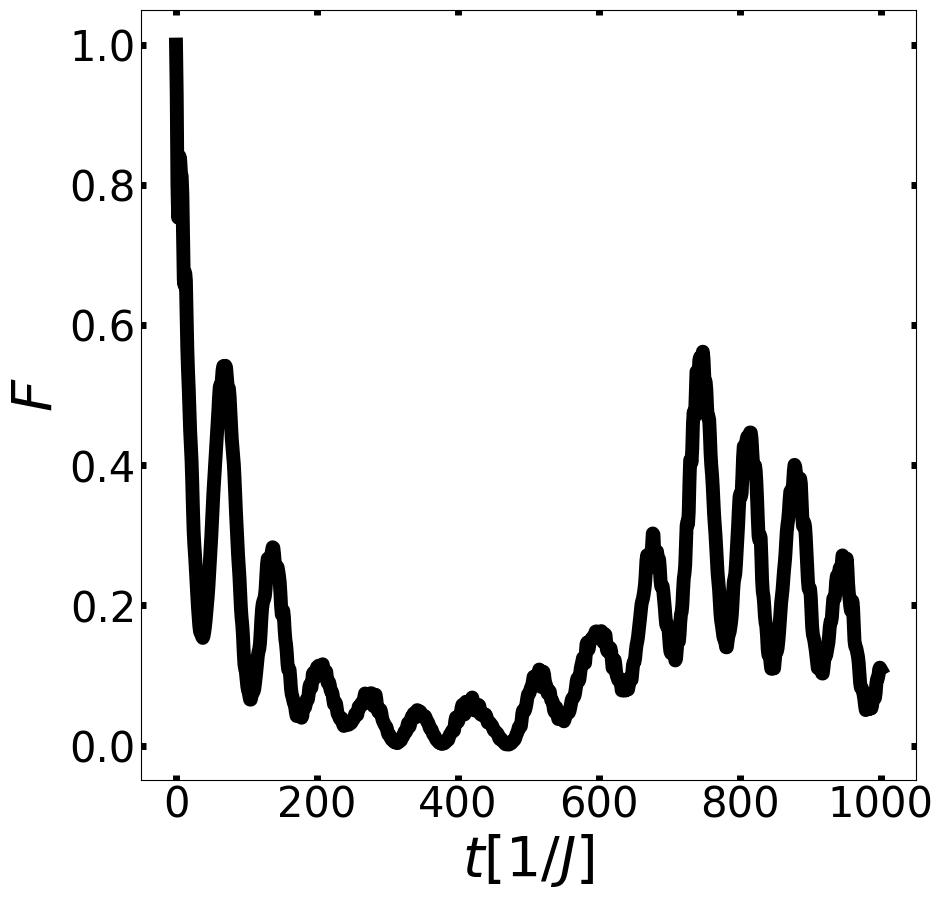

In [103]:


fidelity:np.ndarray=np.conj(np.einsum('ti,i->t',np.conjugate(psi),psi0))*(np.einsum('ti,i->t',np.conjugate(psi),psi0))
print(fidelity.shape)

plt.figure(figsize=(10,10))
plt.plot(time*interaction_coupling,fidelity,color='black',linewidth=10)
plt.xlabel(r'$t[1/J]$',fontsize=40)
plt.ylabel(r'$F$',fontsize=40)
#plt.loglog()
plt.tick_params(
            top=True,
            right=True,
            labeltop=False,
            labelright=False,
            direction="in",
            labelsize=30,
            width=5,
        )
plt.tick_params(
            which='minor',
            top=True,
            right=True,
            labeltop=False,
            labelright=False,
            direction="in",
            labelsize=0,
            width=1,
            length=2
            
        )
plt.show()

Occupation Number

In [104]:
two_particles_n=occupation_number(psi=psi,basis=model_two_particles.basis.vs,size=linear_dimension)

(378, 27)


Comparison with the single particle behaviour and comparison of the time scales

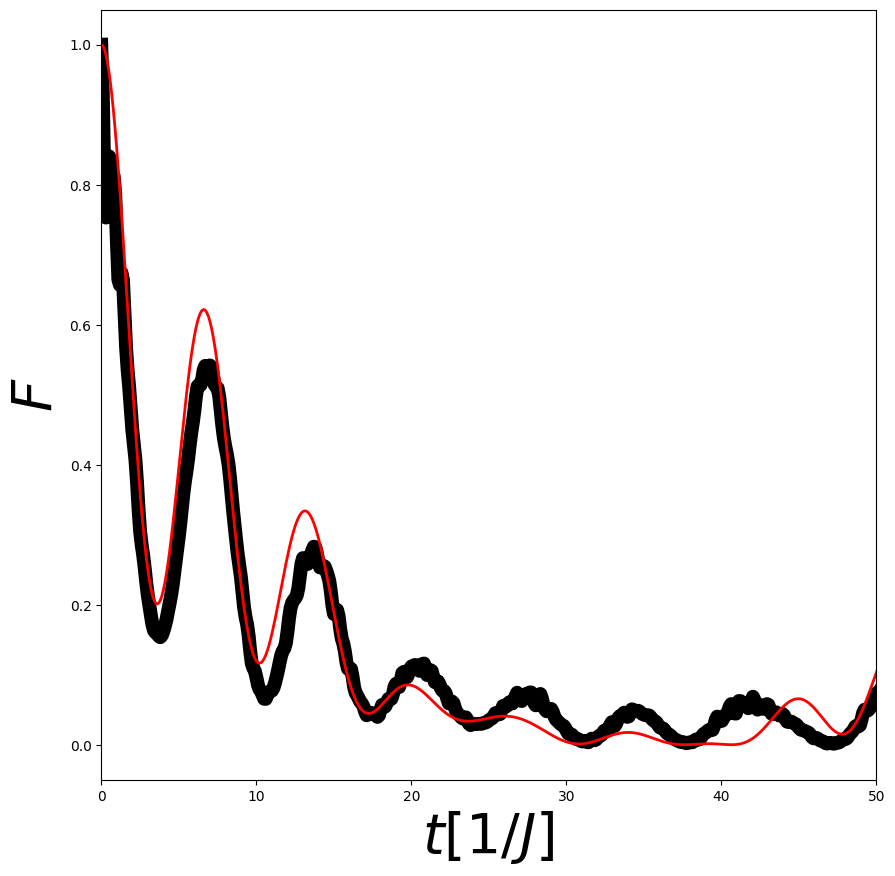

In [105]:
plt.figure(figsize=(10,10))

plt.plot(time,fidelity,color='black',linewidth=10)
plt.plot(time_sp,fidelity_single_particle,color='red',linewidth=2)
plt.xlim([0,50])
plt.xlabel(r'$t[1/J]$',fontsize=40)
plt.ylabel(r'$F$',fontsize=40)
plt.show()

Check of the doublon dynamics

In [ ]:
idx=12

plt.plot(time_sp,single_particle_n[:,idx],label=r'sp $[1/J]$')
plt.plot(time/(0.5*U),two_particles_n[:,idx]/2,label=r'dp $[U/J^2]$')
plt.xlabel(r'$t$',fontsize=20)
plt.legend(fontsize=20)
plt.ylabel(r'$n_{12}$',fontsize=20)
plt.xlim([0,10])
plt.show()
